In [4]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('✅ Ready!')

✅ Ready!


In [5]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/DiseaseSpread/dataset/processed_data/merged_clean.csv'
df = pd.read_csv(DATA_PATH)

print(f'✅ Loaded | Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Mounted at /content/drive
✅ Loaded | Shape: (632, 24)
Columns: ['Unnamed: 0', 'week_label', 'state', 'district', 'disease', 'cases', 'deaths', 'day', 'mon', 'year', 'latitude', 'longitude', 'rainfall_mm', 'leaf_area_index', 'Temp', 'temp_celsius', 'date', 'population', 'area_sq_km', 'density_per_sqkm', 'cases_per_100k', 'season', 'quarter', 'cases_4wk_avg']


,Unnamed: 0,week_label,state,district,disease,cases,deaths,day,mon,year,...,Temp,temp_celsius,date,population,area_sq_km,density_per_sqkm,cases_per_100k,season,quarter,cases_4wk_avg
0,1487,17th week,Tamil Nadu,Ariyalur,Acute Diarrhoeal Disease,6,0.0,26,4,2018,...,314.408,41.26,2018-04-26,2251744.0,NaN,453.49,0.2665,Summer,2,6.00
1,1579,24th week,Tamil Nadu,Ariyalur,Acute Diarrhoeal Disease,9,0.0,12,6,2018,...,312.530,39.38,2018-06-12,2251744.0,NaN,453.49,0.3997,Monsoon,2,7.50
2,792,15th week,Tamil Nadu,Ariyalur,Acute Diarrhoeal Disease,11,0.0,14,4,2019,...,313.964,40.81,2019-04-14,2251744.0,NaN,453.49,0.4885,Summer,2,8.67


In [6]:
import os

output_dir = '/content/outputs/graphs/'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f'✅ Created directory: {output_dir}')
else:
    print(f'Directory already exists: {output_dir}')

✅ Created directory: /content/outputs/graphs/


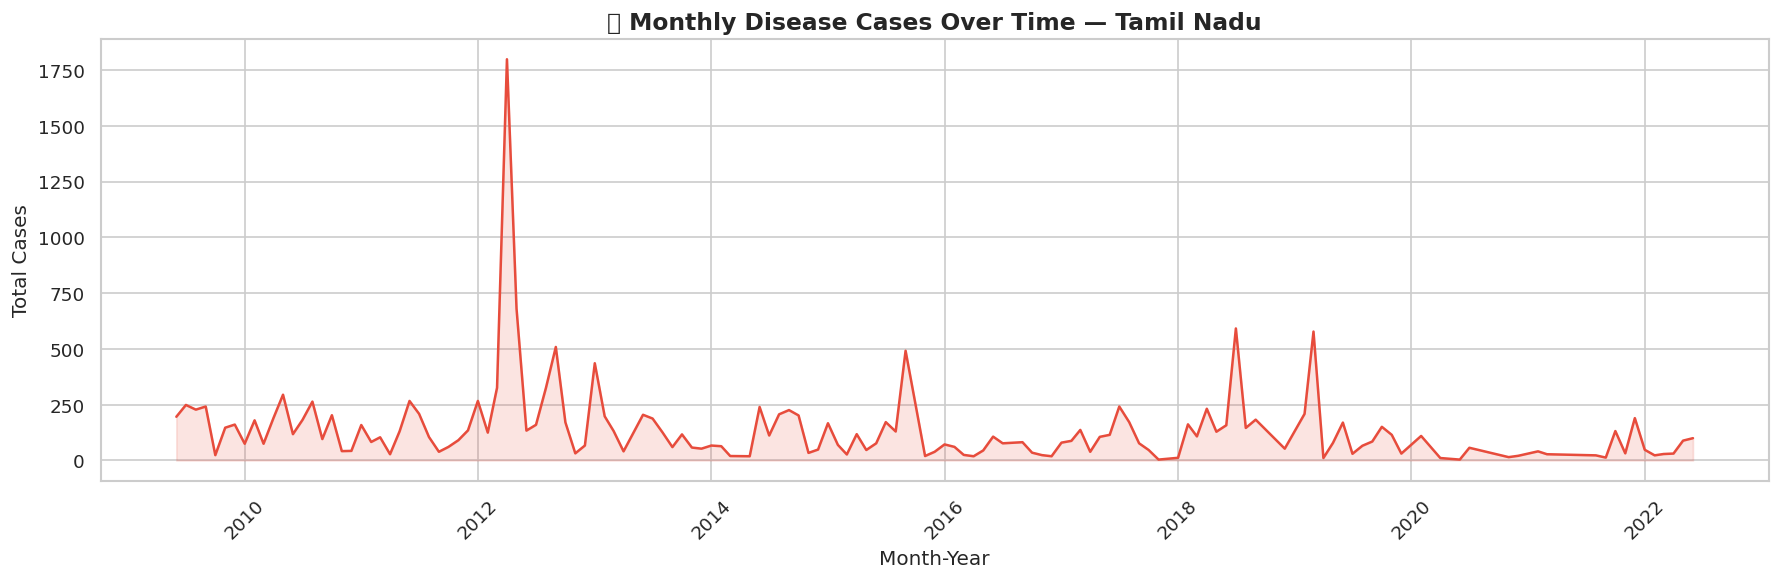

✅ Saved: timeseries_cases.png


In [7]:
import os

# Group by year + month
df['year_month'] = pd.to_datetime(
    df['year'].astype(str) + '-' + df['mon'].astype(str).str.zfill(2)
)
monthly = df.groupby('year_month')['cases'].sum().reset_index()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly['year_month'], monthly['cases'], color='#e74c3c', linewidth=1.5)
ax.fill_between(monthly['year_month'], monthly['cases'], alpha=0.15, color='#e74c3c')
ax.set_title('📅 Monthly Disease Cases Over Time — Tamil Nadu', fontsize=14, fontweight='bold')
ax.set_xlabel('Month-Year')
ax.set_ylabel('Total Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'timeseries_cases.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: timeseries_cases.png')

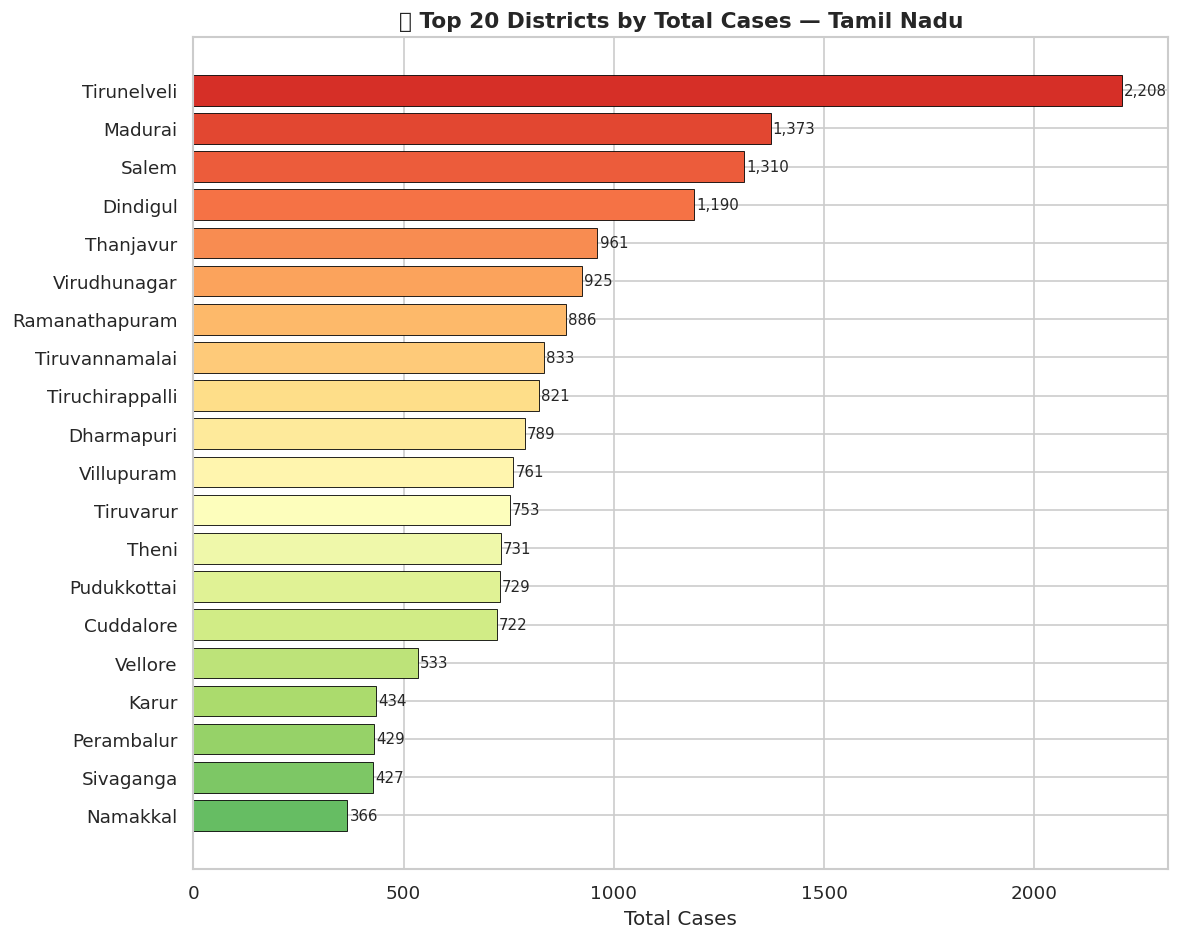

In [8]:
# In visualization notebook — replace the district chart cell with this:

district_cases = df.groupby('district')['cases'].sum().sort_values(ascending=True).tail(20)
colors = cm.RdYlGn_r(np.linspace(0.2, 0.9, len(district_cases)))

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(district_cases.index, district_cases.values,
               color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, district_cases.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)
ax.set_title('🗺️ Top 20 Districts by Total Cases — Tamil Nadu',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Cases')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'cases_by_district.png'), dpi=150, bbox_inches='tight')
plt.show()

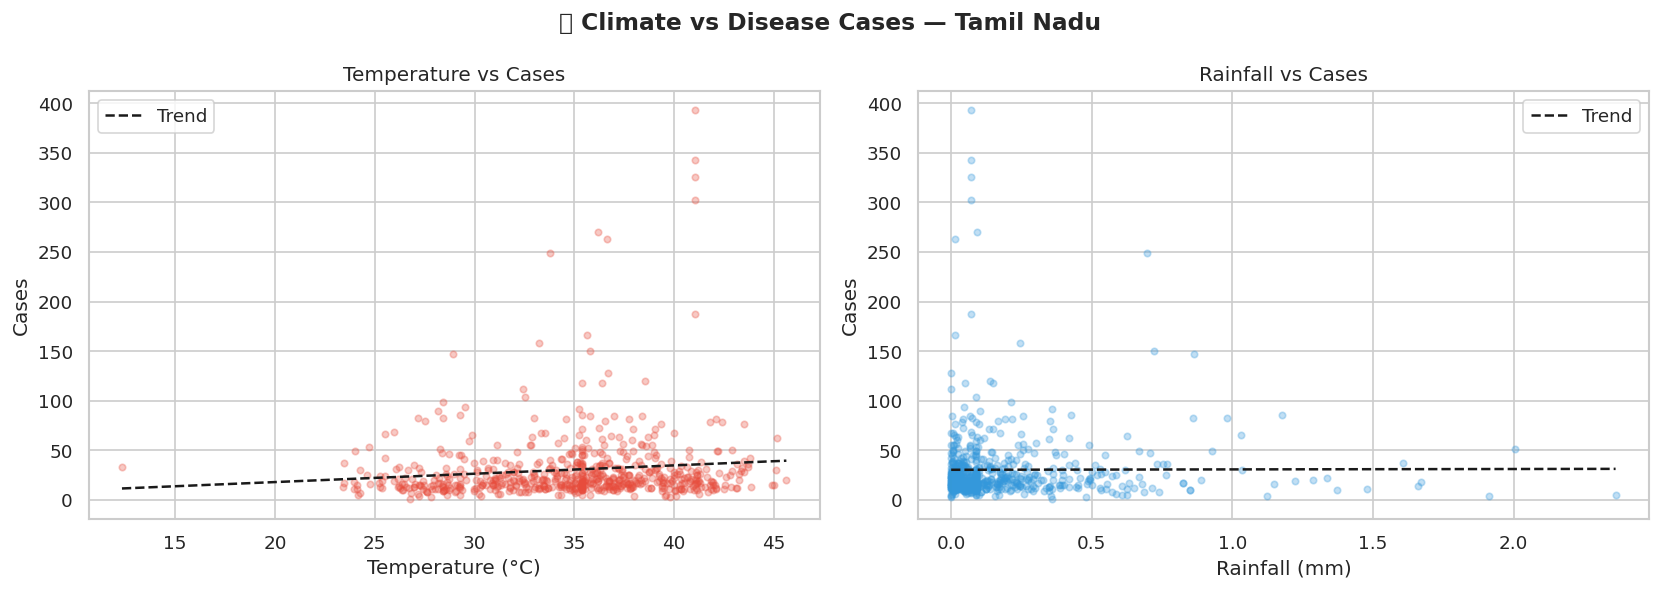

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🌡️ Climate vs Disease Cases — Tamil Nadu', fontsize=14, fontweight='bold')

# Temperature vs Cases
axes[0].scatter(df['temp_celsius'], df['cases'], alpha=0.3, color='#e74c3c', s=15)
z = np.polyfit(df['temp_celsius'].dropna(), df.loc[df['temp_celsius'].notna(),'cases'], 1)
x_range = np.linspace(df['temp_celsius'].min(), df['temp_celsius'].max(), 100)
axes[0].plot(x_range, np.poly1d(z)(x_range), 'k--', linewidth=1.5, label='Trend')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Cases')
axes[0].set_title('Temperature vs Cases')
axes[0].legend()

# Rainfall vs Cases
axes[1].scatter(df['rainfall_mm'], df['cases'], alpha=0.3, color='#3498db', s=15)
z2 = np.polyfit(df['rainfall_mm'].dropna(), df.loc[df['rainfall_mm'].notna(),'cases'], 1)
x_range2 = np.linspace(df['rainfall_mm'].min(), df['rainfall_mm'].max(), 100)
axes[1].plot(x_range2, np.poly1d(z2)(x_range2), 'k--', linewidth=1.5, label='Trend')
axes[1].set_xlabel('Rainfall (mm)')
axes[1].set_ylabel('Cases')
axes[1].set_title('Rainfall vs Cases')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'climate_vs_cases.png'), dpi=150, bbox_inches='tight')
plt.show()

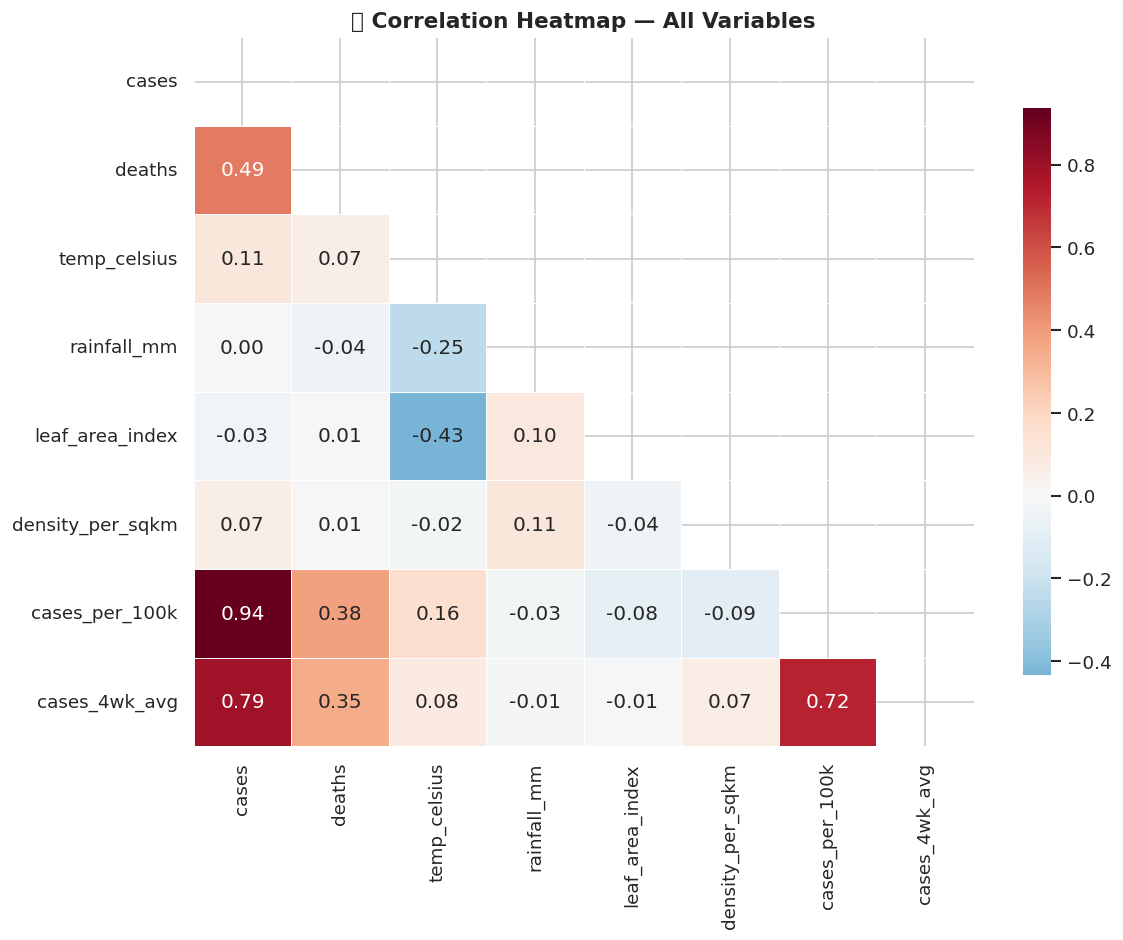

In [10]:
num_cols = ['cases','deaths','temp_celsius','rainfall_mm','leaf_area_index',
            'density_per_sqkm','cases_per_100k','cases_4wk_avg']
# Keep only columns that exist
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('🔥 Correlation Heatmap — All Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
season_disease = df.groupby(['season','disease'])['cases'].sum().reset_index()

fig = px.bar(season_disease, x='season', y='cases', color='disease',
             title='🌀 Disease Cases by Season — Tamil Nadu',
             labels={'cases':'Total Cases','season':'Season'},
             barmode='group',
             category_orders={'season':['Winter','Summer','Monsoon','Post-Monsoon']},
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(plot_bgcolor='white', title_font_size=14)
fig.write_html(os.path.join(output_dir, 'seasonal_patterns.html'))
fig.show()
print('✅ Interactive chart saved: seasonal_patterns.html')

✅ Interactive chart saved: seasonal_patterns.html


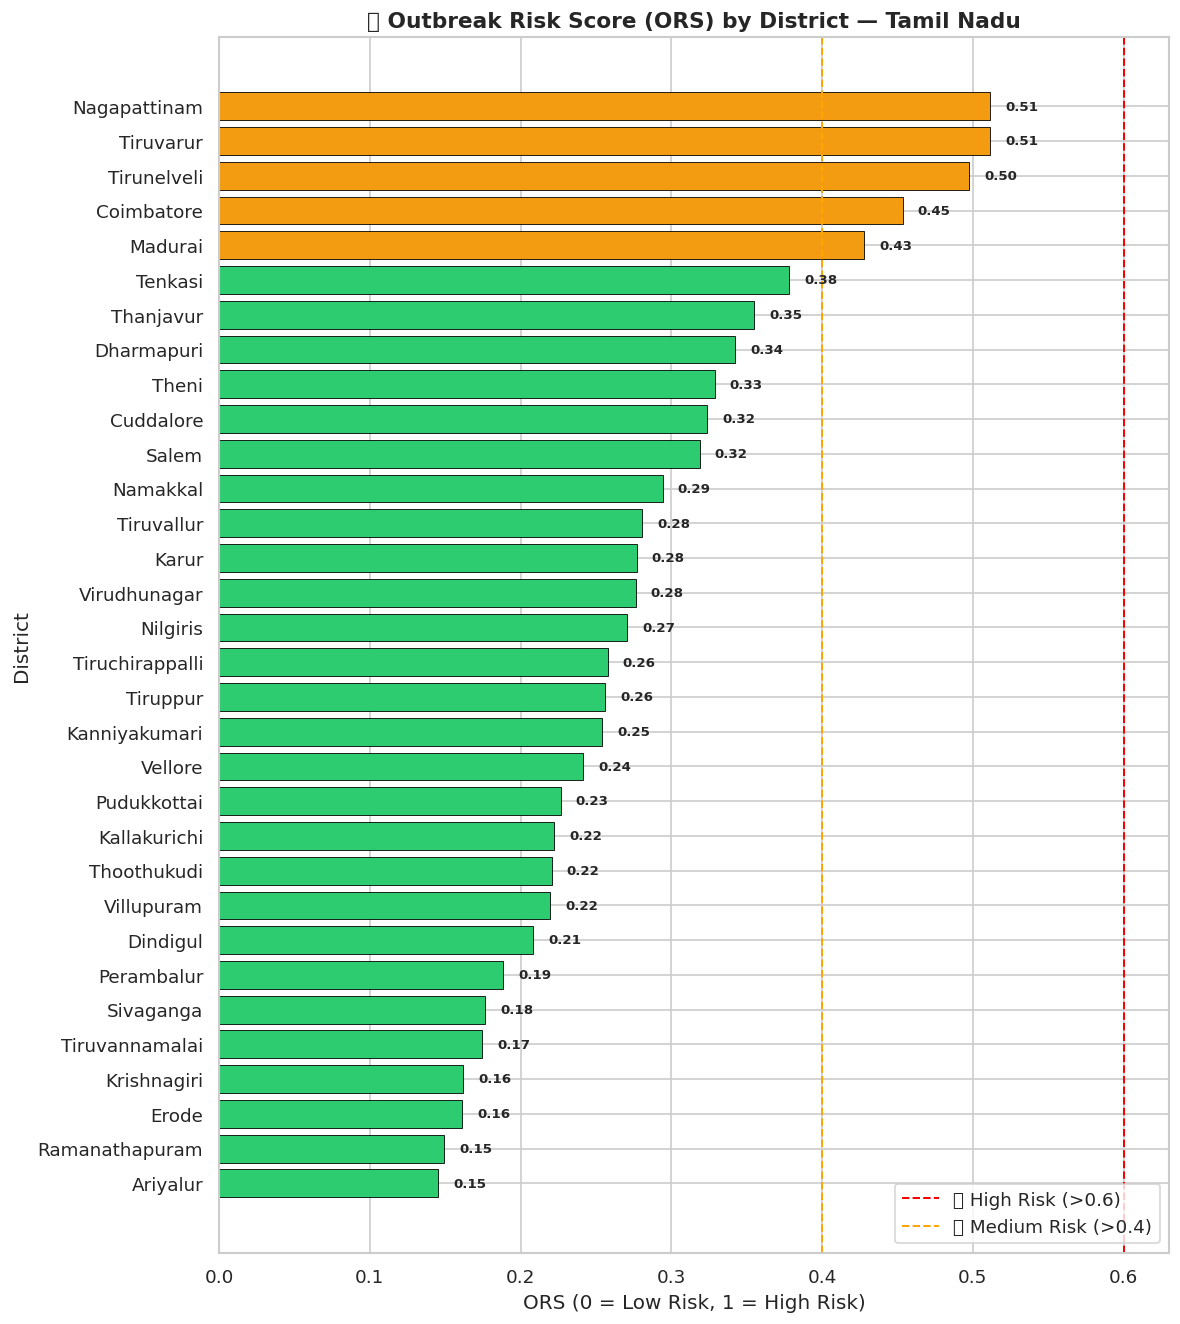


🏆 Final Ranked Districts:
       district    ORS
   Nagapattinam 0.5113
      Tiruvarur 0.5113
    Tirunelveli 0.4975
     Coimbatore 0.4534
        Madurai 0.4281
        Tenkasi 0.3783
      Thanjavur 0.3547
     Dharmapuri 0.3423
          Theni 0.3288
      Cuddalore 0.3238
          Salem 0.3187
       Namakkal 0.2943
     Tiruvallur 0.2806
          Karur 0.2769
   Virudhunagar 0.2763
       Nilgiris 0.2707
Tiruchirappalli 0.2577
       Tiruppur 0.2559
  Kanniyakumari 0.2542
        Vellore 0.2413
    Pudukkottai 0.2266
   Kallakurichi 0.2222
    Thoothukudi 0.2205
     Villupuram 0.2195
       Dindigul 0.2081
     Perambalur 0.1882
      Sivaganga 0.1766
 Tiruvannamalai 0.1745
    Krishnagiri 0.1621
          Erode 0.1610
 Ramanathapuram 0.1494
       Ariyalur 0.1455


In [12]:
from sklearn.preprocessing import MinMaxScaler

# Compute district-level averages
district_summary = df.groupby('district').agg(
    avg_cases    = ('cases', 'mean'),
    avg_rainfall = ('rainfall_mm', 'mean'),
    avg_temp     = ('temp_celsius', 'mean'),
    avg_density  = ('density_per_sqkm', 'mean')
).reset_index()

# Normalize 0–1
scaler = MinMaxScaler()
factors = ['avg_cases','avg_rainfall','avg_temp','avg_density']
district_summary[factors] = scaler.fit_transform(district_summary[factors])

# Weighted ORS
district_summary['ORS'] = (
    0.40 * district_summary['avg_cases'] +
    0.25 * district_summary['avg_rainfall'] +
    0.20 * district_summary['avg_temp'] +
    0.15 * district_summary['avg_density']
).round(4)

district_summary = district_summary.sort_values('ORS', ascending=False).reset_index(drop=True)

# ── Plot — HORIZONTAL bar chart (much more readable) ──────────────
colors = ['#e74c3c' if o > 0.6 else '#f39c12' if o > 0.4 else '#2ecc71'
          for o in district_summary['ORS']]

fig, ax = plt.subplots(figsize=(10, max(8, len(district_summary) * 0.35)))
bars = ax.barh(district_summary['district'][::-1],
               district_summary['ORS'][::-1],
               color=colors[::-1], edgecolor='black', linewidth=0.5)

ax.axvline(0.6, color='red',    linestyle='--', linewidth=1.2, label='🔴 High Risk (>0.6)')
ax.axvline(0.4, color='orange', linestyle='--', linewidth=1.2, label='🟡 Medium Risk (>0.4)')

for bar, val in zip(bars, district_summary['ORS'][::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8, fontweight='bold')

ax.set_title('🏆 Outbreak Risk Score (ORS) by District — Tamil Nadu',
             fontsize=13, fontweight='bold')
ax.set_xlabel('ORS (0 = Low Risk, 1 = High Risk)')
ax.set_ylabel('District')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/outputs/graphs/outbreak_risk_score.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🏆 Final Ranked Districts:')
print(district_summary[['district','ORS']].to_string(index=False))

In [13]:
# Step 1: Better surge label — lower threshold = more surge examples
df_model = df.copy()

temp_dates = df_model[['year', 'mon', 'day']].rename(columns={'mon': 'month'})
df_model['date'] = pd.to_datetime(temp_dates)
df_model['future_date'] = df_model['date'] + pd.DateOffset(months=1)
df_model['future_year'] = df_model['future_date'].dt.year
df_model['future_mon']  = df_model['future_date'].dt.month

monthly_cases = df_model.groupby(
    ['district','disease','year','mon'])['cases'].sum().reset_index()
monthly_cases.columns = ['district','disease','future_year','future_mon','actual_future_cases']

df_model = df_model.merge(
    monthly_cases, on=['district','disease','future_year','future_mon'], how='left')
df_model['actual_future_cases'] = df_model['actual_future_cases'].fillna(0)

stats = df_model.groupby(['district','disease'])['cases'].agg(['mean','std']).reset_index()
stats.columns = ['district','disease','case_mean','case_std']
df_model = df_model.merge(stats, on=['district','disease'], how='left')

# ✅ Changed: 0.3 std instead of 0.5 — creates more surge labels
df_model['surge_threshold'] = df_model['case_mean'] + 0.3 * df_model['case_std']
df_model['surge'] = (df_model['actual_future_cases'] > df_model['surge_threshold']).astype(int)
df_model = df_model.dropna(subset=['actual_future_cases','surge'])

print(f"Surge class balance:\n{df_model['surge'].value_counts()}")
print(f"Surge %: {df_model['surge'].mean()*100:.1f}%")

Surge class balance:
surge
0    594
1     38
Name: count, dtype: int64
Surge %: 6.0%


In [14]:
# Step 2: Features
feature_cols = ['temp_celsius', 'rainfall_mm', 'leaf_area_index', 'mon',
                'cases', 'cases_4wk_avg', 'density_per_sqkm']
feature_cols = [c for c in feature_cols if c in df_model.columns]

df_clean_encoded = pd.get_dummies(df_model, columns=['district','disease'])
encoded_cols = [c for c in df_clean_encoded.columns
                if c.startswith('district_') or c.startswith('disease_')]
final_features = feature_cols + encoded_cols

df_clean = df_clean_encoded[final_features + ['surge']].dropna()
X = df_clean[final_features]
y = df_clean['surge']

print(f"Total samples : {len(X)}")
print(f"Surge samples : {y.sum()} ({y.mean()*100:.1f}%)")

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Surge in test: {y_test.sum()}")

Total samples : 632
Surge samples : 38 (6.0%)
Train: 505  |  Test: 127
Surge in test: 8


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                              roc_auc_score, confusion_matrix, f1_score,
                              precision_recall_curve, roc_curve)
import numpy as np
import matplotlib.pyplot as plt

# ── Train ──────────────────────────────────────────────────────────
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    min_samples_leaf=2,
    random_state=42
)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]

# ── Auto-find best threshold ───────────────────────────────────────
thresholds = np.arange(0.10, 0.55, 0.05)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_t  = round(t, 2)

# ── Apply best threshold & print results ──────────────────────────
y_pred_final = (y_prob >= best_t).astype(int)

print(f"\n{'='*50}")
print(f"Final Results at threshold = {best_t}")
print(f"{'='*50}")
print(f"Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred_final, target_names=['Normal','Surge'])}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_final)}")



Final Results at threshold = 0.35
Accuracy : 0.9528
ROC-AUC  : 0.7836

              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97       119
       Surge       0.62      0.62      0.62         8

    accuracy                           0.95       127
   macro avg       0.80      0.80      0.80       127
weighted avg       0.95      0.95      0.95       127

Confusion Matrix:
[[116   3]
 [  3   5]]


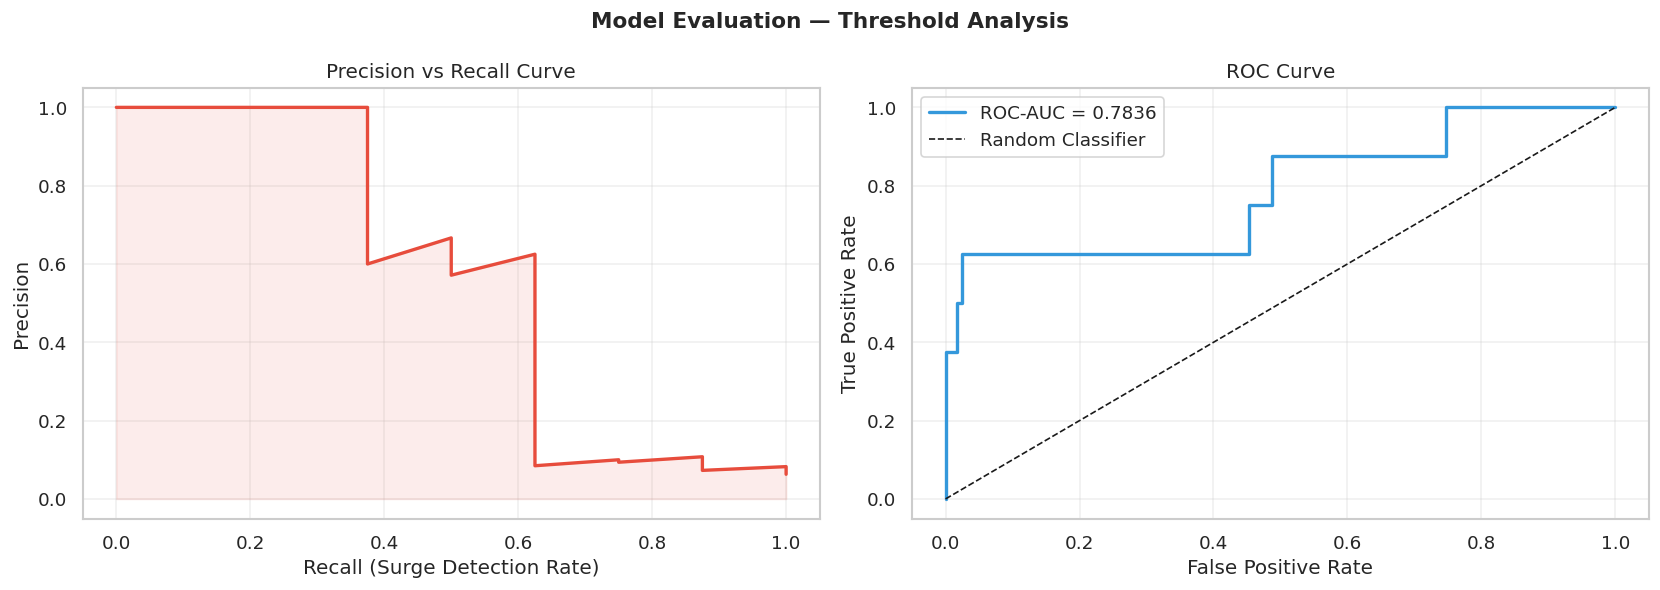

In [20]:
# ── Evaluation Charts ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation — Threshold Analysis', fontsize=13, fontweight='bold')

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
axes[0].plot(recall_vals, precision_vals, color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Recall (Surge Detection Rate)')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision vs Recall Curve')
axes[0].fill_between(recall_vals, precision_vals, alpha=0.1, color='#e74c3c')
axes[0].grid(True, alpha=0.3)

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#3498db', linewidth=2,
             label=f'ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/outputs/graphs/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

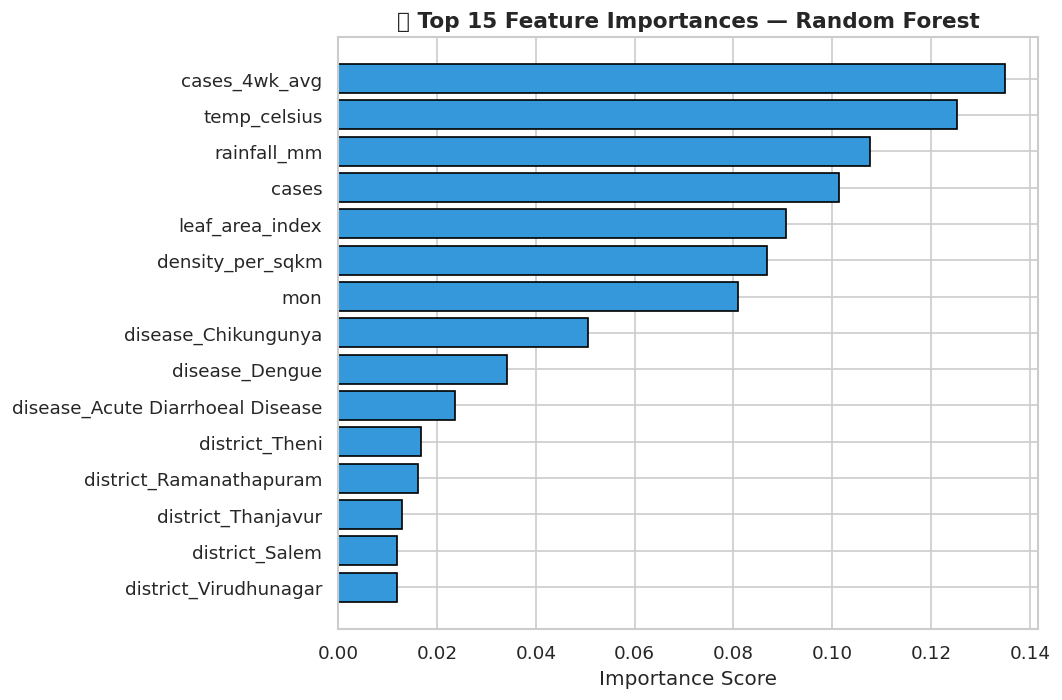

In [21]:
# Step 4: Feature importance chart
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature':    final_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)  # top 15 only

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance['feature'], importance['importance'],
        color='#3498db', edgecolor='black')
ax.set_title('🔑 Top 15 Feature Importances — Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/content/outputs/graphs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()